nstate1_t5-18_svd1e-12_e0prior
nstate1_t6-18_svd1e-12_e0prior
nstate2_t2-10_svd1e-12_fold
nstate2_t2-15_svd1e-12_fold
nstate2_t2-18_svd1e-12_e0prior
nstate2_t3-15_svd1e-04
nstate2_t3-15_svd1e-12
nstate2_t3-15_svd1e-12_fold
nstate2_t3-18_svd1e-12_e0prior
nstate2_t4-12_svd1e-12_fold
nstate2_t4-15_svd1e-12
nstate2_t4-15_svd1e-12_fold
nstate2_t4-18_svd1e-12_e0prior
nstate2_t5-12_svd1e-12_fold
nstate2_t5-15_svd1e-12
nstate2_t5-15_svd1e-12_fold
nstate2_t5-16_svd1e-12_fold
nstate2_t5-17_svd1e-12_fold
nstate2_t5-18_svd1e-12_e0prior
nstate2_t5-18_svd1e-12_fold
nstate2_t6-15_svd1e-12
nstate2_t6-15_svd1e-12_fold
nstate2_t6-18_svd1e-12_e0prior
nstate2_t7-15_svd1e-12_fold
nstate2_t7-18_svd1e-12_e0prior
nstate2_t8-18_svd1e-12_e0prior
nstate3_t1-18_svd1e-12_e0prior
nstate3_t2-18_svd1e-12_e0prior
nstate3_t3-14_svd1e-12_fold
nstate3_t3-15_svd1e-04
nstate3_t3-15_svd1e-04_fold
nstate3_t3-15_svd1e-12
nstate3_t3-15_svd1e-12_e0prior
nstate3_t3-15_svd1e-12_fold
nstate3_t3-18_svd1e-12_e0prior
nstate3_t4-14_sv

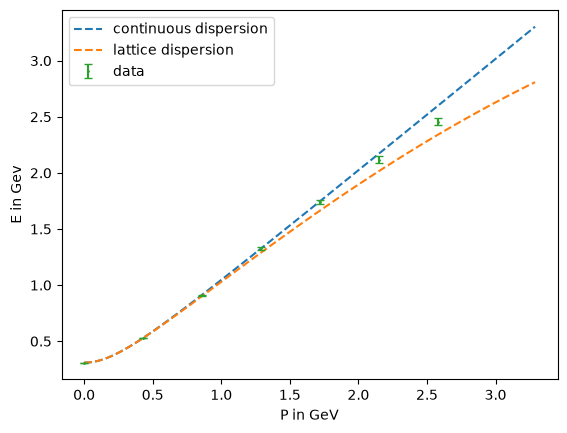

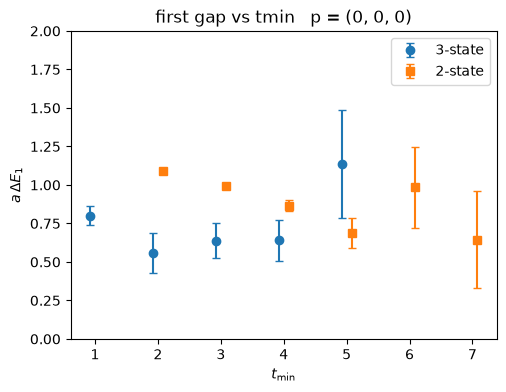

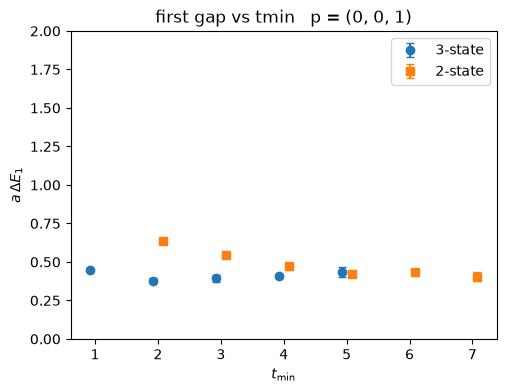

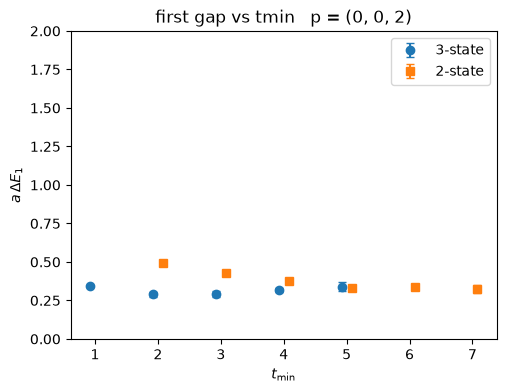

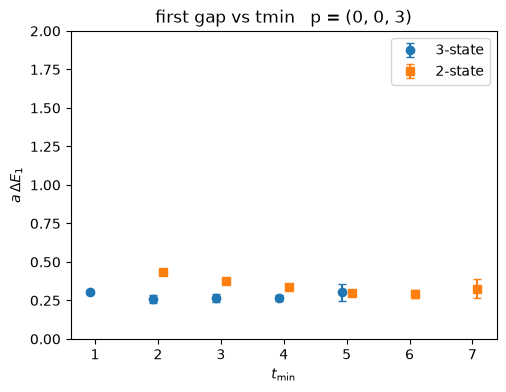

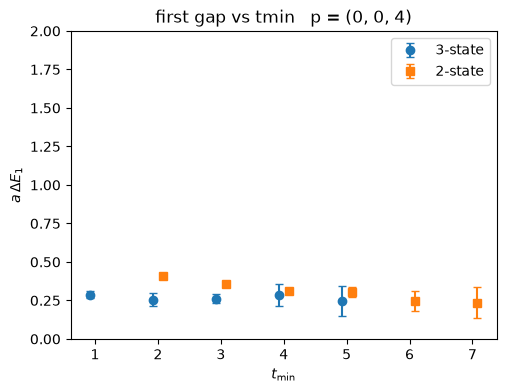

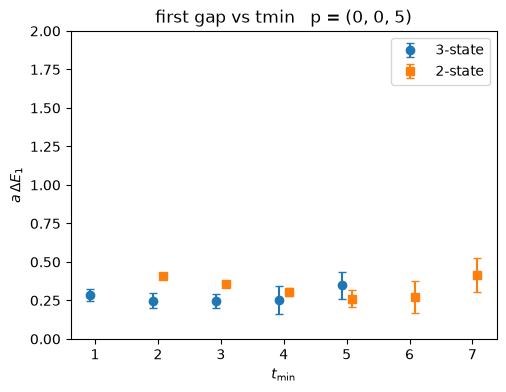

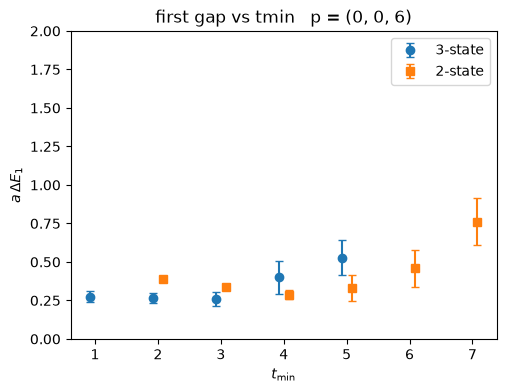

In [4]:
import numpy as np
import h5py 
import matplotlib.pyplot as plt
def jk(data,jk_axis=0):
    n = data.shape[jk_axis]
    #print(n)
    data = np.moveaxis(data, jk_axis, 0)
    #print(f"data has shape {data.shape}")
    mean = np.mean(data,axis=0)
    #print(f"mean has shape {mean.shape}")
    
    err = np.sqrt((n-1.0)/n * np.sum((data-mean)**2,axis=0))
    return mean, err

f = h5py.File("twopt_fit_results.h5", "r")
for name in f:
    print(name)
fit_window = (3,18)
fit_key = f"nstate3_t{fit_window[0]}-{fit_window[1]}_svd1e-12_e0prior" 
#fit_key = f"nstate3_t4-15_svd1e-04_tref10"
for key, value in f[fit_key].items():
    print(f"{key}: {value}")

a=0.09 #fm
a_to_m1 = 1 / 0.09 * 0.1973 #GeV

momentum_list = [[0,0,0],[0,0,1],[0,0,2],[0,0,3],[0,0,4],[0,0,5],[0,0,6]]

E_jk = np.zeros((799,7,3))  #n_jk, n_p, n_state
for ip, p  in enumerate(momentum_list):
    E_jk[:,ip,:] = f[fit_key][f"p{p[0]}_{p[1]}_{p[2]}"]["E_jk"]
    #print(f"ground state dE0 = {np.mean(dE_jk[:,ip,:],axis=0)[0]}")
    #print(f"ground state E0 = {np.mean(E_jk[:,ip,:],axis=0)[0]}")

E0_jk = E_jk[:,:,0]
m = np.mean(E0_jk[:,0])
p_line = np.linspace(0,1.5,100) #p in unit of a, 2pi/L included
E_con = np.sqrt(p_line**2  + m**2  ) 
E_lat = 2*np.arcsinh(np.sqrt(np.sinh(m/2)**2 + np.sin(p_line/2)**2))

#plot continuous dispersion relation
plt.plot(p_line*a_to_m1,E_con*a_to_m1,ls="dashed",label="continuous dispersion")
#plot lattice dispersion relation
plt.plot(p_line*a_to_m1, E_lat*a_to_m1, ls="dashed", label="lattice dispersion")
mom = 2*np.pi/32 * np.linalg.norm(momentum_list, axis=1)    
E0_jk_mean, E0_jk_err = jk(E0_jk)
plt.errorbar(mom*a_to_m1, E0_jk_mean*a_to_m1, E0_jk_err*a_to_m1, marker="o", markersize=1,ls="none", capsize=3, label="data")

plt.legend()
plt.xlabel("P in GeV")
plt.ylabel("E in Gev")

tmin_list_3state = [1,2,3,4,5]
tmin_list_2state = [2,3,4,5,6,7] # (typo fixed: lsit -> list)
n_p = len(momentum_list)

# first-gap mean and error, indexed [tmin, momentum]
gap3_mean = np.zeros((len(tmin_list_3state), n_p))
gap3_err  = np.zeros((len(tmin_list_3state), n_p))
gap2_mean = np.zeros((len(tmin_list_2state), n_p))
gap2_err  = np.zeros((len(tmin_list_2state), n_p))

for itmin, tmin in enumerate(tmin_list_3state):
    fit_key_read = f"nstate3_t{tmin}-{fit_window[1]}_svd1e-12_e0prior"
    for ip, p in enumerate(momentum_list):
        d = f[fit_key_read][f"p{p[0]}_{p[1]}_{p[2]}"]["dE_jk"][:, 1]   # first-gap replicates
        gap3_mean[itmin, ip], gap3_err[itmin, ip] = jk(d)

for itmin, tmin in enumerate(tmin_list_2state):
    fit_key_read = f"nstate2_t{tmin}-{fit_window[1]}_svd1e-12_e0prior"
    for ip, p in enumerate(momentum_list):
        d = f[fit_key_read][f"p{p[0]}_{p[1]}_{p[2]}"]["dE_jk"][:, 1]
        gap2_mean[itmin, ip], gap2_err[itmin, ip] = jk(d)

for ip, p in enumerate(momentum_list):
    plt.figure(figsize=(5.5, 4))
    plt.errorbar(np.array(tmin_list_3state) - 0.08, gap3_mean[:, ip],
                 yerr=gap3_err[:, ip], marker="o", ls="none", capsize=3,
                 label="3-state")
    plt.errorbar(np.array(tmin_list_2state) + 0.08, gap2_mean[:, ip],
                 yerr=gap2_err[:, ip], marker="s", ls="none", capsize=3,
                 label="2-state")
    plt.xlabel(r"$t_{\rm min}$")
    plt.ylabel(r"$a\,\Delta E_1$")
    plt.title(f"first gap vs tmin   p = {tuple(p)}")
    plt.xticks(range(min(tmin_list_3state), max(tmin_list_2state) + 1))
    plt.legend()
    plt.ylim(0,2)
    


